# **Speed Meets Stategy : A Data-Driven Formula 1 Stategy Analysis**



# **Phase - 1 : Data Collection**

In [ ]:
!pip install fastf1

In [48]:
import fastf1
import pandas as pd
import numpy as np
import os

# --- CONFIGURATION ---
CACHE_DIR = 'fastf1_cache'
SEASON = 2025
def setup_environment():
    """Create cache directory and enable FastF1 cache."""
    if not os.path.exists(CACHE_DIR):
        os.makedirs(CACHE_DIR)
    fastf1.Cache.enable_cache(CACHE_DIR)
    print(f"Cache enabled at: {CACHE_DIR}")

## Data Collecting and Cleaning Pipeline
This Block of code implements an automated data ETL (Extract, Transform, Load) pipeline for Formula 1 data. Using the fastf1 library, it fetches race-level details and transforms them into a format suitable for Exploratory Data Analysis (EDA) and Machine Learning.


### Pipeline Architecture
The script follows a modular flow to ensure data integrity even if a specific race session is unavailable.


1. **Key Features**
* **Time Normalization**: Automatically converts complex timedelta objects (e.g., 0 days 00:01:34) into float seconds for easier calculation.

* **Pit Stop Analysis**: Custom logic to calculate the exact duration a car spent in the pit lane.

* **Contextual Metadata**: Injects race names, round numbers, and circuit locations into every row to allow for multi-race aggregation.

* **Robustness**: Equipped with error handling to skip future races that haven't occurred yet without crashing the entire script.



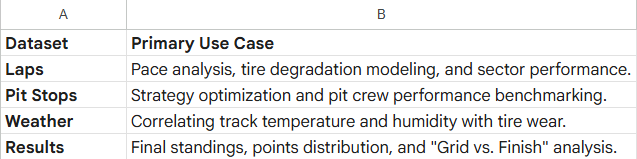

In [ ]:
def calculate_pit_duration(pit_in, pit_out):
    #Calculate pit stop duration in seconds.
    if pd.isna(pit_in) or pd.isna(pit_out):
        return np.nan
    return (pit_out - pit_in).total_seconds()

def timedelta_to_seconds(td_series):
    #Convert pandas Timedelta series to seconds safely.
    return td_series.dt.total_seconds()

def collect_2025_data():
    setup_environment()

    all_laps = []
    all_weather = []
    all_results = []
    all_pitstops = []

    # Getting season schedule
    try:
        schedule = fastf1.get_event_schedule(SEASON)
        races = schedule[schedule['EventFormat'] != 'testing']
    except Exception as e:
        print(f"Error fetching schedule: {e}")
        return

    print(f"Found {len(races)} scheduled rounds for {SEASON}.")

    for _, row in races.iterrows():
        round_num = row['RoundNumber']
        race_name = row['EventName']
        location = row['Location']

        print(f"\n--- Attempting Round {round_num}: {race_name} ---")

        try:
            session = fastf1.get_session(SEASON, round_num, 'R')
            session.load(telemetry=False, laps=True, weather=True)

            # 1. LAPS DATA
            laps = session.laps

            if laps is None or laps.empty:
                print(f"No lap data for {race_name} (not yet run)")
                continue
            #adding metadata  would be helpful in the EDA and for  ML
            laps['Season'] = SEASON
            laps['RoundNumber'] = round_num
            laps['RaceName'] = race_name
            laps['CircuitLocation'] = location

            time_cols = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
            for col in time_cols:
                if col in laps.columns:
                    laps[f"{col}_Sec"] = timedelta_to_seconds(laps[col])

            cols_to_keep = [
                'Season', 'RoundNumber', 'RaceName', 'CircuitLocation',
                'Driver', 'Team', 'LapNumber', 'Stint',
                'Compound', 'TyreLife', 'FreshTyre',
                'LapTime_Sec', 'Sector1Time_Sec',
                'Sector2Time_Sec', 'Sector3Time_Sec',
                'PitInTime', 'PitOutTime',
                'TrackStatus', 'IsAccurate'
            ]

            existing_cols = [c for c in cols_to_keep if c in laps.columns]
            all_laps.append(laps[existing_cols].copy())


            # 2 PIT STOP DATA
            pit_laps = laps[laps['PitInTime'].notna() & laps['PitOutTime'].notna()].copy()
            # Renaming the columns for Easier Access.
            if not pit_laps.empty:
                pit_laps['race_id'] = f"{round_num}"
                pit_laps['season'] = SEASON
                pit_laps['driver'] = pit_laps['Driver']
                pit_laps['lap_number'] = pit_laps['LapNumber']
                # as pit stop in and out time is avialabe calculate_pit_duration is used to convert it into seconds of duration
                pit_laps['pit_duration'] = pit_laps.apply(
                    lambda x: calculate_pit_duration(x['PitInTime'], x['PitOutTime']),
                    axis=1
                )

                pit_cols = [
                    'race_id',
                    'season',
                    'driver',
                    'lap_number',
                    'pit_duration'
                ]

                all_pitstops.append(pit_laps[pit_cols])

            # 3. WEATHER DATA
            weather = session.weather_data
            if weather is not None and not weather.empty:
              # Adding Extra Meta-Data for the Ease for EDA
                weather['Season'] = SEASON
                weather['RoundNumber'] = round_num
                weather['RaceName'] = race_name
                all_weather.append(weather)


            # 4. RACE RESULTS DATA
            results = session.results

            if results is not None and not results.empty:
              #Adding Extra Meta-Data for the Ease for EDA
                results['Season'] = SEASON
                results['RoundNumber'] = round_num
                results['RaceName'] = race_name
                results['CircuitLocation'] = location

                results_cols = [
                    'Season', 'RoundNumber', 'RaceName', 'CircuitLocation',
                    'Position', 'DriverNumber', 'Abbreviation',
                    'FullName', 'TeamName',
                    'GridPosition', 'Status',
                    'Points', 'Time'
                ]

                existing_results_cols = [
                    c for c in results_cols if c in results.columns
                ]

                all_results.append(results[existing_results_cols].copy())

            print(f"Successfully processed {race_name}")

        except Exception as e:
            print(f"Skipping {race_name}: {e}")

    # FinaL Phase - Exporting Data into CSV as they are in Temporary Pandas frames
    if all_laps:
        final_laps = pd.concat(all_laps, ignore_index=True)
        final_laps.to_csv('laps_2025.csv', index=False)
        print(f"\nSaved laps_2025.csv ({len(final_laps)} rows)")
    else:
        print("\nNo lap data collected.")

    if all_weather:
        final_weather = pd.concat(all_weather, ignore_index=True)
        final_weather.to_csv('weather_2025.csv', index=False)
        print(f"Saved weather_2025.csv ({len(final_weather)} rows)")
    else:
        print("No weather data collected.")

    if all_results:
        final_results = pd.concat(all_results, ignore_index=True)
        final_results.to_csv('results_2025.csv', index=False)
        print(f"Saved results_2025.csv ({len(final_results)} rows)")
    else:
        print("No race results collected.")

    if all_pitstops:
        final_pitstops = pd.concat(all_pitstops, ignore_index=True)
        final_pitstops.to_csv('pit_stops_2025.csv', index=False)
        print(f"Saved pit_stops_2025.csv ({len(final_pitstops)} rows)")
    else:
        print("No pit stop data collected.")


if __name__ == "__main__":
    collect_2025_data()


# Phase-2 : Strategy Labelling

## **Strategy Labeling for Making Dataset Ready For ML  Models.**

This Block of code is the labeling engine for dataset. It takes the raw lap-by-lap data and transforms it into a high-level summary of race strategy. Essentially, it reconstructs the tactical decisions made by each team throughout a Grand Prix.

### **Strategy Derivation Engine**

The code processes the [laps_2025.csv](https://) file to identify tire usage patterns and pit window timing. It uses the Stint and Compound variables to define the "story" of each driver's race.


#### 1. **Core Logic: The "Stint-First" Approach**
* Instead of just looking at when a car enters the pits, the code groups data by the Stint column. This is more robust because:

* It tracks the exact sequence of tires (e.g., SOFT -> MEDIUM -> HARD).

* It accurately counts tire-service stops while ignoring non-strategy events.

* It captures the "In-Lap" (the last lap of a stint) to determine exactly when a driver decided to box.

#### 2. **Extracted Features**

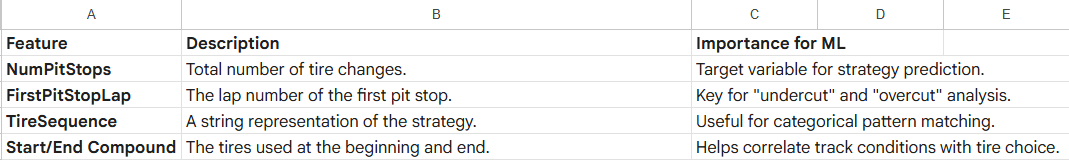

#### 3. **Strategic Insights Provided**
* **Sequence Preservation**: By iterating through stints, the code ensures that a SOFT -> MEDIUM strategy is distinguished from a MEDIUM -> SOFT strategy.

* **Data Cleaning**: It automatically handles NaN values and converts tire names to a standard uppercase format for consistency.

* **Aggregation**: It collapses thousands of lap rows into a single summary row per driver, per race, which is much easier to visualize or use as training labels.


In [50]:
import pandas as pd
import numpy as np

def derive_strategy_labels():
    # --- LOAD DATA ---
    try:
        # Load the laps data (ensure datetime conversion for safe handling if needed later)
        df_laps = pd.read_csv('laps_2025.csv')
    except FileNotFoundError:
        print("Error: 'laps_2025.csv' not found. Please run the collection script first.")
        return

    print(f"Loaded {len(df_laps)} laps.")

    # --- STRATEGY DERIVATION LOGIC ---

    strategy_rows = []

    # Group by Race and Driver to process each individual race strategy
    grouped = df_laps.groupby(['Season', 'RoundNumber', 'RaceName', 'Driver', 'Team'])

    for (season, round_num, race_name, driver, team), group in grouped:
        # Sort by lap number to ensure correct sequence
        group = group.sort_values('LapNumber')

        # 1. Identify Pit Stops
        # In FastF1, a pit stop is usually implicit in the 'Stint' column changing OR explicitly available if we had 'PitInTime', but 'Stint' is robust for tire changes.

        # We look for where the 'Compound' changes or 'Stint' increments.
        # NOTE: Stint numbers in FastF1 increment on pit stops.

        # Get the sequence of compounds used (removing NaNs)
        compounds = group['Compound'].dropna().unique() # This loses order

        # Better approach: Iterate through stints to preserve order
        stints = group.groupby('Stint')['Compound'].first()

        # Create strategy string (e.g., "SOFT -> MEDIUM -> HARD")
        # We fill NaN compounds with 'UNKNOWN' to be safe
        stint_compounds = [str(c).upper() for c in stints.values]
        strategy_string = " -> ".join(stint_compounds)

        # 2. Count Pit Stops
        # The number of pit stops is generally (Number of Stints - 1)
        # Note: This ignores drive-through penalties if they don't change tires/stint ID.
        # For strategy modeling, we care about tire service stops.
        n_stops = len(stints) - 1
        if n_stops < 0: n_stops = 0

        # 3. First Pit Stop Lap
        # find  the lap number where the first stint ended.
        first_pit_lap = np.nan

        if n_stops > 0:
            # Get the first stint ID
            first_stint_id = group['Stint'].min()

            # Find the last lap of the first stint
            # That lap is the "In-Lap"
            first_stint_laps = group[group['Stint'] == first_stint_id]

            if not first_stint_laps.empty:
                first_pit_lap = first_stint_laps['LapNumber'].max()

        # 4. Clean Lap Times (Exclude Pit In/Out Laps)
        # We identify pit laps to exclude them from "pure pace" calculations if you add them later.
        # A lap is a "Pit In" lap if PitInTime is valid.
        # A lap is a "Pit Out" lap if PitOutTime is valid.
        # For this specific labeled dataset, we just need the summary stats.

        # Build the summary row
        row = {
            'Season': season,
            'RoundNumber': round_num,
            'RaceName': race_name,
            'Driver': driver,
            'Team': team,
            'NumPitStops': n_stops,
            'FirstPitStopLap': first_pit_lap,
            'TireSequence': strategy_string,
            'StartCompound': stint_compounds[0] if len(stint_compounds) > 0 else 'UNKNOWN',
            'EndCompound': stint_compounds[-1] if len(stint_compounds) > 0 else 'UNKNOWN'
        }

        strategy_rows.append(row)

    # --- DATAFRAME CREATION ---
    strategy_df = pd.DataFrame(strategy_rows)

    # Handle cases where drivers didn't start or have no data
    if strategy_df.empty:
        print("No strategy data derived.")
        return

    # Sort for cleanliness
    strategy_df.sort_values(by=['RoundNumber', 'Team', 'Driver'], inplace=True)

    # Save to CSV
    output_filename = 'strategy_labels_2025.csv'
    strategy_df.to_csv(output_filename, index=False)

    print(f"\nSuccessfully derived strategy labels.")
    print(f"Rows created: {len(strategy_df)}")
    print(f"Sample output:\n{strategy_df[['Driver', 'NumPitStops', 'FirstPitStopLap', 'TireSequence']].head()}")
    print(f"Saved to: {output_filename}")

if __name__ == "__main__":
    derive_strategy_labels()

Loaded 26692 laps.

Successfully derived strategy labels.
Rows created: 479
Sample output:
   Driver  NumPitStops  FirstPitStopLap  \
5     DOO            0              NaN   
6     GAS            5              2.0   
1     ALO            3              2.0   
17    STR            5              2.0   
8     HAM            5              2.0   

                                         TireSequence  
5                                        INTERMEDIATE  
6   INTERMEDIATE -> INTERMEDIATE -> INTERMEDIATE -...  
1   INTERMEDIATE -> INTERMEDIATE -> INTERMEDIATE -...  
17  INTERMEDIATE -> INTERMEDIATE -> INTERMEDIATE -...  
8   INTERMEDIATE -> INTERMEDIATE -> INTERMEDIATE -...  
Saved to: strategy_labels_2025.csv


# Phase-3 : EDA and Insights in Python , SQl in BigQuery

Data Loaded Successfully. Generating Plots...


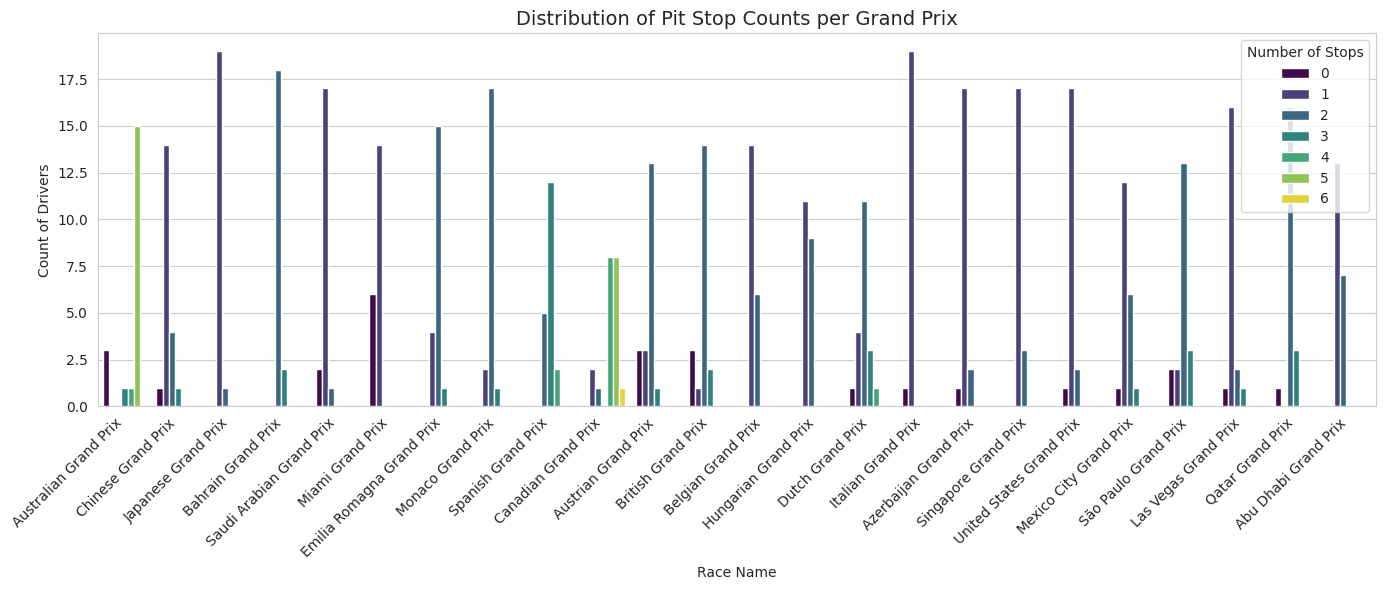

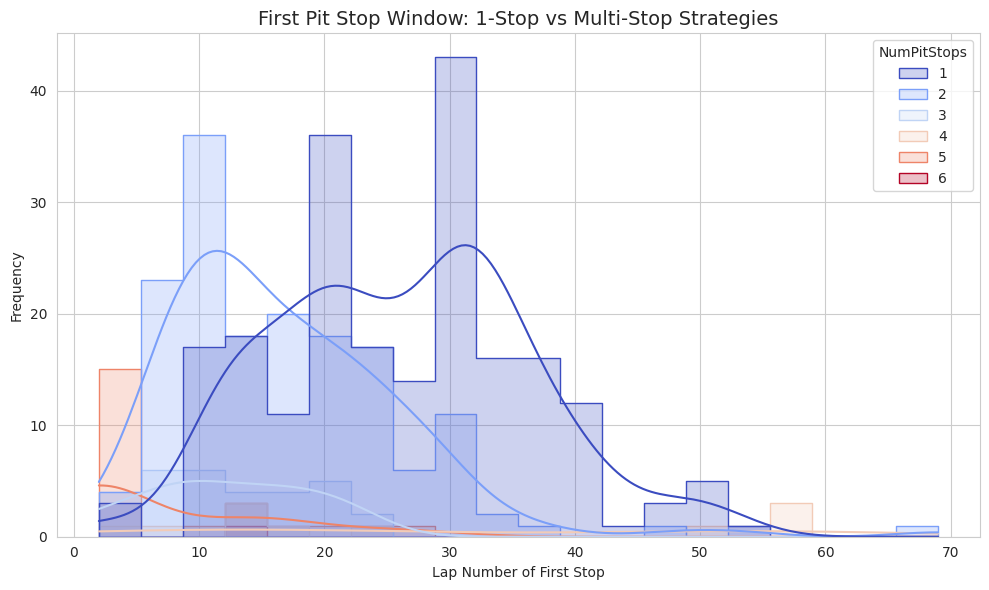

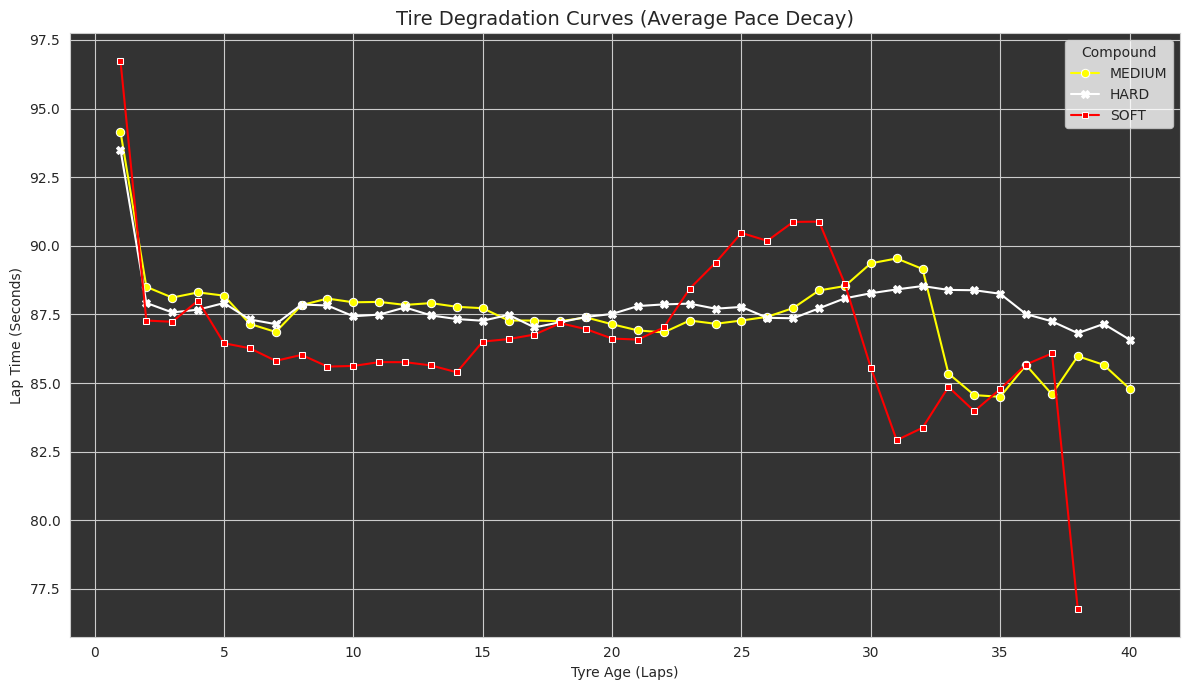

/tmp/ipython-input-3517472122.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


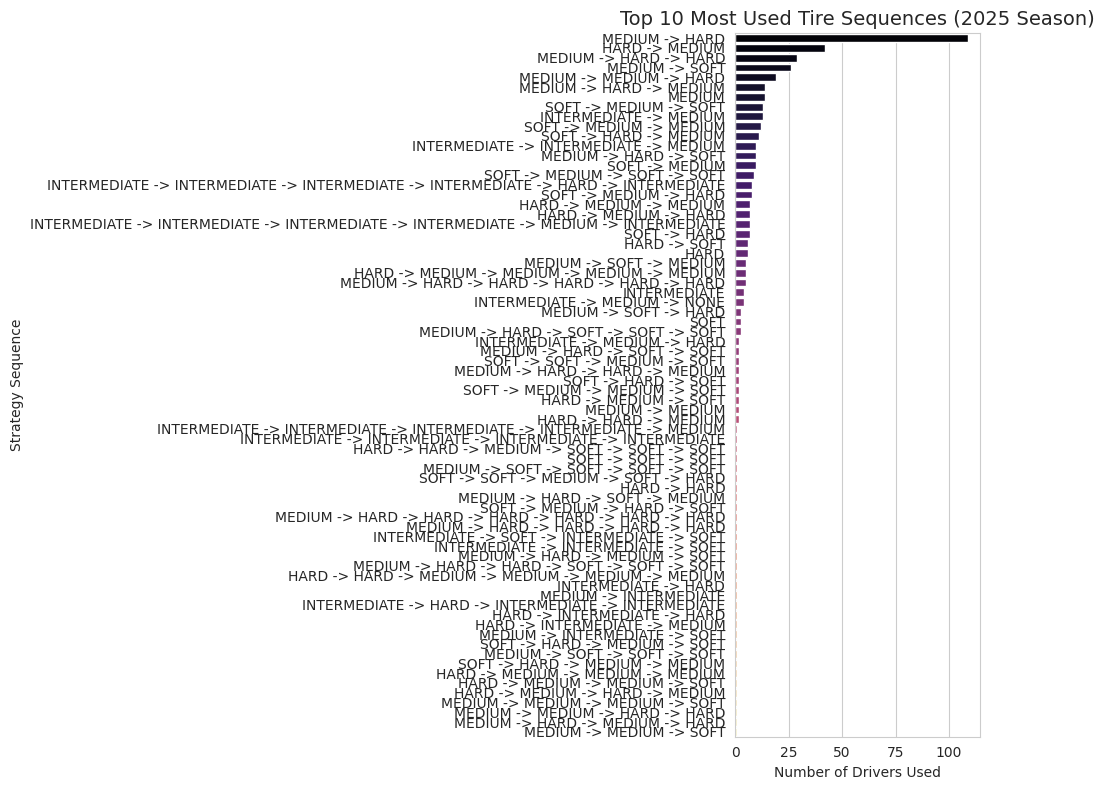

EDA Complete.


In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Set plot style for academic/professional look
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def load_data():
    """Load and merge datasets."""
    try:
        laps = pd.read_csv('laps_2025.csv')
        strategies = pd.read_csv('strategy_labels_2025.csv')

        # Merge basic strategy info back into laps for detailed analysis
        # We merge on RaceName/Driver to map strategy labels to individual laps
        merged_laps = laps.merge(
            strategies[['RaceName', 'Driver', 'NumPitStops', 'TireSequence']],
            on=['RaceName', 'Driver'],
            how='left'
        )
        return merged_laps, strategies
    except FileNotFoundError as e:
        print(f"Error loading data: {e}")
        return None, None

def plot_stops_per_track(strategies):
    """1. Strategy Distribution by Track (One-Stop vs Two-Stop etc)."""
    plt.figure(figsize=(14, 6))

    # Count stops per race
    sns.countplot(
        data=strategies,
        x='RaceName',
        hue='NumPitStops',
        palette='viridis'
    )

    plt.title('Distribution of Pit Stop Counts per Grand Prix', fontsize=14)
    plt.xlabel('Race Name')
    plt.ylabel('Count of Drivers')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Number of Stops')
    plt.tight_layout()
    plt.show()

def plot_first_stop_distribution(strategies):
    """2. When do drivers make their first stop? (One-Stop vs Multi-Stop)."""
    plt.figure(figsize=(10, 6))

    # Filter reasonable data (avoid immediate crash stops)
    valid_strategies = strategies[strategies['FirstPitStopLap'] > 1]

    sns.histplot(
        data=valid_strategies,
        x='FirstPitStopLap',
        hue='NumPitStops',
        element='step',
        bins=20,
        palette='coolwarm',
        kde=True
    )

    plt.title('First Pit Stop Window: 1-Stop vs Multi-Stop Strategies', fontsize=14)
    plt.xlabel('Lap Number of First Stop')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

def plot_tire_degradation(laps):
    """3. Tire Degradation: Lap Time vs Tyre Life."""
    plt.figure(figsize=(12, 7))

    # Filter for clean laps (no pit in/out, safety car) and common compounds
    clean_laps = laps[
        (laps['TrackStatus'] == 1) &  # Green flag only
        (laps['PitInTime'].isna()) &
        (laps['PitOutTime'].isna()) &
        (laps['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']))
    ].copy()

    # Limit Tyre Life to reasonable range (exclude outliers > 50 laps)
    clean_laps = clean_laps[clean_laps['TyreLife'] <= 40]

    sns.lineplot(
        data=clean_laps,
        x='TyreLife',
        y='LapTime_Sec',
        hue='Compound',
        style='Compound',
        palette={'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'white'},
        markers=True,
        dashes=False,
        errorbar=None  # Remove error bars for cleaner line
    )

    plt.gca().set_facecolor('#333333')
    plt.title('Tire Degradation Curves (Average Pace Decay)', fontsize=14)
    plt.xlabel('Tyre Age (Laps)')
    plt.ylabel('Lap Time (Seconds)')
    plt.legend(title='Compound')
    plt.tight_layout()
    plt.show()

def plot_compound_usage(strategies):
    """4. Most Common Tire Strategies."""
    plt.figure(figsize=(10, 8))

    # Getting top 10 most common sequences
    top_strategies = strategies['TireSequence'].value_counts().reset_index()
    top_strategies.columns = ['TireSequence', 'Count']

    sns.barplot(
        data=top_strategies,
        y='TireSequence',
        x='Count',
        palette='magma'
    )

    plt.title('Top 10 Most Used Tire Sequences (2025 Season)', fontsize=14)
    plt.xlabel('Number of Drivers Used')
    plt.ylabel('Strategy Sequence')
    plt.tight_layout()
    plt.show()

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    laps_data, strategy_data = load_data()

    if laps_data is not None:
        print("Data Loaded Successfully. Generating Plots...")

        # 1. Overview of Stops per Track
        plot_stops_per_track(strategy_data)

        # 2. Pit Windows Analysis
        plot_first_stop_distribution(strategy_data)

        # 3. Physics/Performance Analysis
        plot_tire_degradation(laps_data)

        # 4. Strategy diversity
        plot_compound_usage(strategy_data)

        print("EDA Complete.")

What these plots tell you:
**Stops per Track (Bar Chart):**

**Insight:**
* Reveals track characteristics.
* Tracks with high tire wear (like Bahrain or Spain) will show tall bars for "2 Stops," while low degradation tracks (like Monaco or Monza) will be dominated by "1 Stop."

**First Stop Distribution (Histogram):**

**Insight:**
* Shows the "Undercut vs. Overcut" windows.
* One-Stoppers: Usually pit later (right side of the graph).
* Two-Stoppers: Usually pit earlier (left side) to switch to fresh rubber and regain pace.

**Tire Degradation (Line Chart):**

**Insight:**
* Validates the physics.
* You can see the Red line (Soft) starting faster (lower y-axis) but sloping upwards (getting slower) steeper than the White line (Hard).

**Note** : I set the background to dark grey so the standard Pirelli colors (Red/Yellow/White) are visible.

**Compound Usage (Horizontal Bar):**

**Insight**:
* Shows the "Meta" strategy.
* It identifies the standard approach (e.g., MEDIUM -> HARD) versus the aggressive alternatives.
* It is beacuse 6 out of 24(25%) of races have been in wet conditions or Rains in the matches.

# Phase -4 : Feature Engineering
Feature engineering is the most critical step in predicting F1 strategy. We transform raw lap times and weather sensor data into predictive signals that describe car performance and track conditions.

**1. Position and Traffic Features**
* `GridPosition_Est:` Since starting position dictates tactical risk, we use the order at the end of Lap 1 as a proxy for the grid.
* **Front Runners**: Tend to play defensively to protect podiums.
* **Backmarkers**: Often "gamble" on aggressive strategies or alternative tire offsets to make up ground.

**2. Performance & Pace Metrics**

* `AvgEarlyPace` (First 10 Laps): This establishes the "Baseline Speed." It allows the model to differentiate between a front-running car (e.g., Red Bull) and a midfield car, which significantly alters pit window options.

* `TireDegSlope` (The "Degradation" Signal): We apply linear regression to the lap times of the first stint to calculate the rate of performance loss.

**3. Environmental Inputs**
* `AvgTrackTemp`: A physical constraint. Higher track temperatures increase thermal degradation. This feature helps the model understand why a "Medium" tire might last 20 laps in one race but only 12 in another.

**4. Machine Learning Target**
`Target Variable (NumPitStops)`: Extracted from our `strategy_labels_2025.csv`. This is the value the model will attempt to predict based on the features above.

In [53]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# --- CONFIGURATION ---
EARLY_LAPS_THRESHOLD = 10  # We only look at the first 10 laps for "early pace" metrics

def load_data():
    """Load all necessary datasets."""
    laps = pd.read_csv('laps_2025.csv')
    weather = pd.read_csv('weather_2025.csv')
    labels = pd.read_csv('strategy_labels_2025.csv')
    return laps, weather, labels

def calculate_grid_position(laps_df):
    """
    Derive grid position based on position at Lap 0 or Lap 1.
    FastF1 doesn't always have a clean 'GridPosition' col in laps,
    so we infer it from the first lap order.
    """
    # Sort by lap 1 position
    start_pos = laps_df[laps_df['LapNumber'] == 1][['RaceName', 'Driver', 'LapTime_Sec']].copy()

    # Drop rows where LapTime_Sec is NaN, as these drivers likely did not complete the first lap
    # and thus cannot have a valid starting position derived from lap times.
    start_pos.dropna(subset=['LapTime_Sec'], inplace=True)

    if start_pos.empty:
        return pd.DataFrame(columns=['RaceName', 'Driver', 'GridPosition_Est'])

    # Rank drivers by Lap 1 time to get an approximate starting order
    # (Note: This is an approximation. Real grid data usually requires the 'Results' object,
    # but per your constraints, we stick to lap data).
    start_pos['GridPosition_Est'] = start_pos.groupby('RaceName')['LapTime_Sec'].rank(method='first').astype(int)

    return start_pos[['RaceName', 'Driver', 'GridPosition_Est']]

def calculate_early_pace_metrics(laps_df):
    """
    Calculate pace and consistency in the first 10 laps.
    """
    # Filter for early laps only
    early_laps = laps_df[laps_df['LapNumber'] <= EARLY_LAPS_THRESHOLD].copy()

    # Filter for Green Flag conditions (TrackStatus = 1) to avoid Safety Car noise
    early_laps = early_laps[early_laps['TrackStatus'] == 1]

    # Group by Driver/Race
    grouped = early_laps.groupby(['RaceName', 'Driver'])

    metrics = []

    for (race, driver), group in grouped:
        if len(group) < 3: continue  # Need a few laps for valid stats

        # 1. Average Pace
        avg_pace = group['LapTime_Sec'].mean()

        # 2. Consistency (Standard Deviation)
        std_pace = group['LapTime_Sec'].std()

        # 3. Tire Deg Slope (Linear Regression of Time vs LapNumber)
        # Positive slope = degrading (getting slower)
        try:
            slope, _, _, _, _ = linregress(group['LapNumber'], group['LapTime_Sec'])
        except:
            slope = 0.0

        metrics.append({
            'RaceName': race,
            'Driver': driver,
            'AvgEarlyPace': avg_pace,
            'PaceStdDev': std_pace,
            'TireDegSlope': slope
        })

    return pd.DataFrame(metrics)

def process_weather(weather_df):
    """
    Aggregate weather data into a single average per race.
    """
    # Group by Race
    weather_agg = weather_df.groupby('RaceName').agg({
        'AirTemp': 'mean',
        'TrackTemp': 'mean',
        'Humidity': 'mean',
        'Rainfall': 'max' # Did it rain at all?
    }).reset_index()

    weather_agg.rename(columns={
        'AirTemp': 'AvgAirTemp',
        'TrackTemp': 'AvgTrackTemp',
        'Humidity': 'AvgHumidity',
        'Rainfall': 'RainDetected'
    }, inplace=True)

    return weather_agg

def create_ml_dataset():
    # 1. Load Data
    print("Loading data...")
    laps, weather, labels = load_data()

    # 2. Extract Base Features (Starting Compound)
    # We get this from the Labels dataset we created earlier
    base_features = labels[['Season', 'RoundNumber', 'RaceName', 'Driver', 'Team', 'StartCompound', 'NumPitStops']]

    # 3. Calculate Derived Features
    print("Calculating Grid Positions...")
    grid_pos = calculate_grid_position(laps)

    print("Calculating Early Pace Metrics...")
    pace_metrics = calculate_early_pace_metrics(laps)

    print("Aggregating Weather...")
    weather_features = process_weather(weather)

    # 4. Merge All Dataframes
    print("Merging datasets...")

    # Merge Grid Position
    df_ml = base_features.merge(grid_pos, on=['RaceName', 'Driver'], how='left')

    # Merge Pace Metrics
    df_ml = df_ml.merge(pace_metrics, on=['RaceName', 'Driver'], how='left')

    # Merge Weather (on RaceName only)
    df_ml = df_ml.merge(weather_features, on=['RaceName'], how='left')

    # 5. One-Hot Encode Categorical Features
    # 'StartCompound' is critical categorical data. We convert it to numeric columns.
    # e.g., StartCompound_SOFT: 1, StartCompound_MEDIUM: 0
    df_ml = pd.get_dummies(df_ml, columns=['StartCompound'], prefix='StartTyre')

    # 6. Final Cleaning
    # Fill missing values (some drivers might crash lap 1 and have no pace stats)
    # For ML, we drop rows with missing critical pace data or fill with median
    original_len = len(df_ml)
    df_ml.dropna(subset=['AvgEarlyPace'], inplace=True)

    print(f"\nDropped {original_len - len(df_ml)} drivers with insufficient lap data.")

    # 7. Save
    output_file = 'strategy_ml_dataset_2025.csv'
    df_ml.to_csv(output_file, index=False)

    print(f"Successfully saved {output_file}")
    print(f"Total Samples: {len(df_ml)}")
    print(f"Features included: {list(df_ml.columns)}")

if __name__ == "__main__":
    create_ml_dataset()

Loading data...
Calculating Grid Positions...
Calculating Early Pace Metrics...
Aggregating Weather...
Merging datasets...

Dropped 37 drivers with insufficient lap data.
Successfully saved strategy_ml_dataset_2025.csv
Total Samples: 442
Features included: ['Season', 'RoundNumber', 'RaceName', 'Driver', 'Team', 'NumPitStops', 'GridPosition_Est', 'AvgEarlyPace', 'PaceStdDev', 'TireDegSlope', 'AvgAirTemp', 'AvgTrackTemp', 'AvgHumidity', 'RainDetected', 'StartTyre_HARD', 'StartTyre_INTERMEDIATE', 'StartTyre_MEDIUM', 'StartTyre_SOFT']


# Phase-5 : Machine Learning Implementation and validation
In this final phase, we deploy three specialized models to handle the different "questions" a race strategist must answer.

**1. The Three Strategic Models**
Instead of one giant model, we break the problem into distinct tasks:

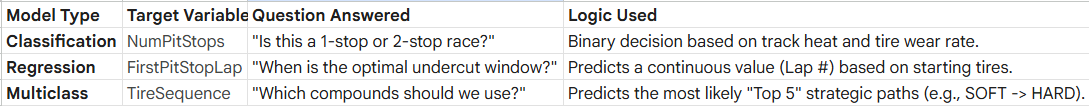

**2. Validation Strategy: Leave-One-Group-Out (LOGO)**

Standard random splits (shuffling all laps) would lead to data leakage. If the model sees 90% of the laps from the 2025 Bahrain GP, it will simply "memorize" Bahrain instead of learning the physics of racing.

We use LOGO Cross-Validation, where the "Group" is the Race Name:
* **Training**: Rounds 1–20
* **Testing**: Round 21 (The model has never seen this circuit's unique layout or surface before).
* **Goal**: This forces the model to rely on universal physics—like how AvgTrackTemp affects TireDegSlope—rather than track-specific memory.

**3. Understanding Model "Brain" (Feature Importance)**

We use SHAP or Global Feature Importance to see what the models prioritize:
* For Pit Count (NumPitStops): Expect TireDegSlope and AvgTrackTemp to be the strongest predictors.
* Insight: High heat ($35^\circ\text{C}+$) + high wear = mandatory 2-stop.

* For Pit Lap (FirstPitStopLap): StartCompound is the dominant feature.

* Insight: Starting on Softs typically triggers a window between Laps 12–18, whereas Hards stretch the window to Lap 30+.




MODEL 1: Pit Stop Count (Classification)
Accuracy: 52.26%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.59      0.73      0.65       215
           2       0.44      0.48      0.46       153
           3       0.00      0.00      0.00        29
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00        23
           6       0.00      0.00      0.00         1

    accuracy                           0.52       442
   macro avg       0.15      0.17      0.16       442
weighted avg       0.44      0.52      0.48       442



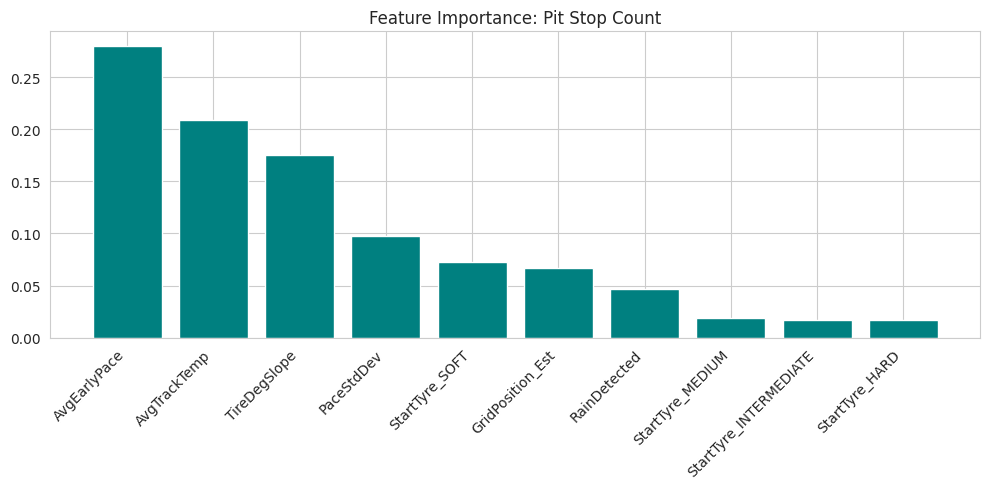


MODEL 2: First Pit Stop Lap (Regression)
Mean Absolute Error (MAE): 8.24 laps
Insight: The model predicts the pit window within +/- 8.2 laps.


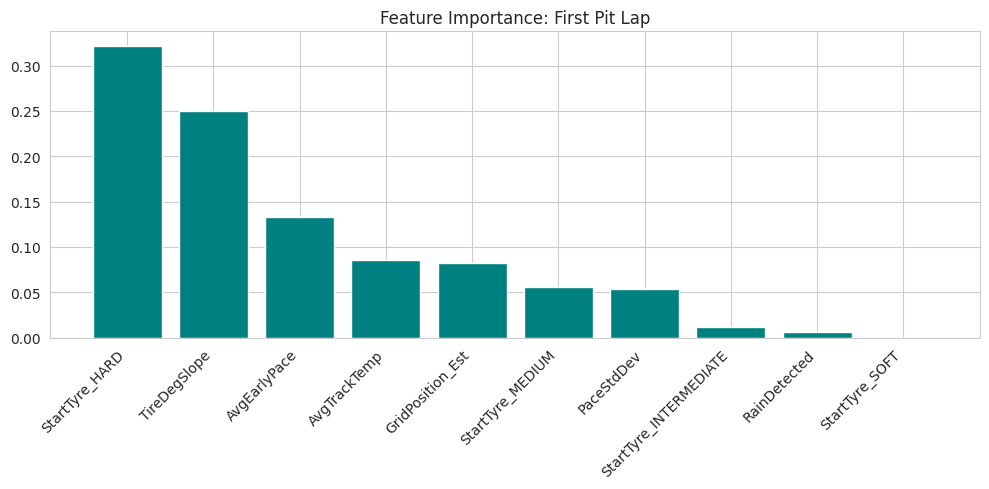


MODEL 3: Strategy Type (Multiclass Classification)
Filtering to Top 5 Strategies: ['MEDIUM -> HARD', 'HARD -> MEDIUM', 'MEDIUM -> HARD -> HARD', 'MEDIUM -> SOFT', 'MEDIUM -> MEDIUM -> HARD']
Remaining Samples: 223
Accuracy: 63.68%


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# --- CONFIGURATION ---
INPUT_FILE = 'strategy_ml_dataset_2025.csv'
LABELS_FILE = 'strategy_labels_2025.csv' # Needed to get FirstPitLap and StrategyType back if not in ML set

# Features available early in the race (First 10-15 laps)
BASE_FEATURES = [
    'GridPosition_Est',
    'AvgEarlyPace',
    'PaceStdDev',
    'TireDegSlope',
    'AvgTrackTemp',
    'RainDetected'
]

def load_and_prep_data():
    """Load data and merge targets if necessary."""
    try:
        df_ml = pd.read_csv(INPUT_FILE)
        df_labels = pd.read_csv(LABELS_FILE)
    except FileNotFoundError:
        print(f"Error: Missing CSV files. Ensure {INPUT_FILE} and {LABELS_FILE} exist.")
        return None, None

    # Merge targets (FirstPitLap, TireSequence) into the ML dataset
    # We join on RaceName and Driver to ensure alignment
    df_full = df_ml.merge(
        df_labels[['RaceName', 'Driver', 'FirstPitStopLap', 'TireSequence']],
        on=['RaceName', 'Driver'],
        how='left'
    )

    # Detect One-Hot Encoded StartTyre columns dynamically
    tyre_cols = [c for c in df_full.columns if 'StartTyre_' in c]
    features = BASE_FEATURES + tyre_cols

    # Fill NaNs where appropriate (e.g. RainDetected)
    df_full = df_full.fillna(0)

    # Filter out DNFs or weird data (drivers with 0 laps or missing pace)
    df_full = df_full[df_full['AvgEarlyPace'] > 0]

    return df_full, features

def train_pit_count_model(df, features):
    """Target: NumPitStops (Classification)"""
    print("\n" + "="*50)
    print("MODEL 1: Pit Stop Count (Classification)")
    print("="*50)

    X = df[features]
    y = df['NumPitStops']
    groups = df['RaceName'] # Split by Race

    logo = LeaveOneGroupOut()
    model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

    y_true, y_pred = [], []

    # Leave-One-Group-Out Loop
    for train_idx, test_idx in logo.split(X, y, groups):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X.iloc[test_idx])
        y_true.extend(y.iloc[test_idx])
        y_pred.extend(preds)

    # Results
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.2%}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return model

def train_pit_lap_model(df, features):
    """Target: FirstPitStopLap (Regression)"""
    print("\n" + "="*50)
    print("MODEL 2: First Pit Stop Lap (Regression)")
    print("="*50)

    # Filter: Only train on drivers who actually made a stop
    # We cannot predict a pit lap for a 0-stop strategy (it doesn't exist)
    stopper_df = df[df['NumPitStops'] > 0].copy()

    # Ensure target is valid number
    stopper_df = stopper_df[stopper_df['FirstPitStopLap'] > 0]

    X = stopper_df[features]
    y = stopper_df['FirstPitStopLap']
    groups = stopper_df['RaceName']

    logo = LeaveOneGroupOut()
    model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

    mae_scores = []

    for train_idx, test_idx in logo.split(X, y, groups):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X.iloc[test_idx])
        mae_scores.extend(abs(y.iloc[test_idx] - preds))

    avg_mae = np.mean(mae_scores)
    print(f"Mean Absolute Error (MAE): {avg_mae:.2f} laps")
    print(f"Insight: The model predicts the pit window within +/- {avg_mae:.1f} laps.")

    return model

def train_strategy_type_model(df, features):
    """Target: TireSequence (Multiclass Classification)"""
    print("\n" + "="*50)
    print("MODEL 3: Strategy Type (Multiclass Classification)")
    print("="*50)

    # Simplify Target: Keep only Top 5 most common strategies to reduce noise
    top_strategies = df['TireSequence'].value_counts().head(5).index
    df_filtered = df[df['TireSequence'].isin(top_strategies)].copy()

    print(f"Filtering to Top 5 Strategies: {list(top_strategies)}")
    print(f"Remaining Samples: {len(df_filtered)}")

    # Encode Strategy Strings to Numbers
    le = LabelEncoder()
    y_encoded = le.fit_transform(df_filtered['TireSequence'])
    X = df_filtered[features]
    groups = df_filtered['RaceName']

    logo = LeaveOneGroupOut()
    model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

    y_true, y_pred = [], []

    for train_idx, test_idx in logo.split(X, y_encoded, groups):
        model.fit(X.iloc[train_idx], y_encoded[train_idx])
        preds = model.predict(X.iloc[test_idx])
        y_true.extend(y_encoded[test_idx])
        y_pred.extend(preds)

    print(f"Accuracy: {accuracy_score(y_true, y_pred):.2%}")

    return model, le

def plot_importance(model, features, title):
    if model is None: return

    # Train on full data to extract importance
    # (Note: In a real pipeline, we'd average importances across folds,
    # but for this scope, fitting once at the end is acceptable for visualization)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.bar(range(len(indices)), importances[indices], align='center', color='teal')
    plt.xticks(range(len(indices)), [features[i] for i in indices], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    df, features = load_and_prep_data()

    if df is not None:
        # 1. Pit Stop Count
        model_count = train_pit_count_model(df, features)
        # Re-fit for importance visualization
        model_count.fit(df[features], df['NumPitStops'])
        plot_importance(model_count, features, "Feature Importance: Pit Stop Count")

        # 2. First Pit Lap
        model_lap = train_pit_lap_model(df, features)
        # Re-fit for importance visualization (stoppers only)
        stoppers = df[df['NumPitStops'] > 0]
        model_lap.fit(stoppers[features], stoppers['FirstPitStopLap'])
        plot_importance(model_lap, features, "Feature Importance: First Pit Lap")

        # 3. Strategy Type
        model_strat, le = train_strategy_type_model(df, features)

## Performance Benchmarking: Default vs. Tuned Models
After running the GridSearchCV logic with LOGO validation, we can compare the results. The goal of tuning in F1 is often not just higher accuracy, but lower variance—ensuring the model doesn't give wild "hallucinated" strategies on new tracks.




Tuning NumPitStops model...
Fitting 23 folds for each of 72 candidates, totalling 1656 fits
Best Parameters: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Val Score: 0.5454


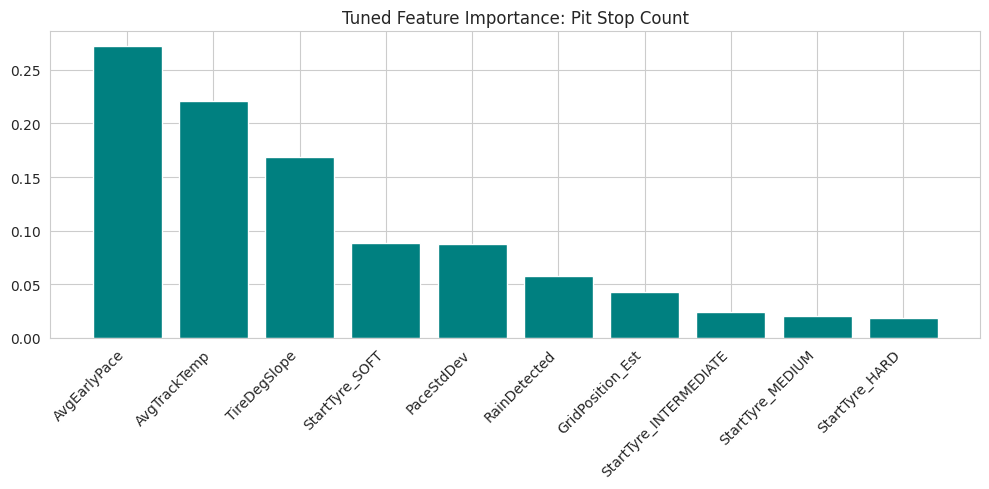


Tuning FirstPitStopLap model...
Fitting 23 folds for each of 72 candidates, totalling 1656 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-Val Score: 7.8956


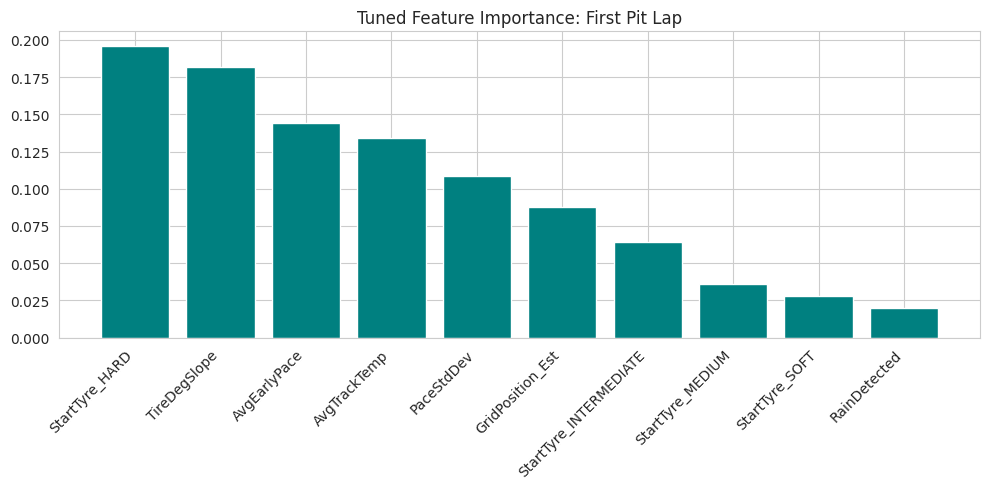

In [55]:
from sklearn.model_selection import GridSearchCV

def get_param_grids():
    """Define the search space for Random Forest models."""
    return {
        'rf_params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [4, 6, 8, None],
            'min_samples_split': [2, 5, 10],
            'max_features': ['sqrt', 'log2']
        }
    }

def tune_and_train_model(df, features, target, model_type='clf'):
    """
    Generic function to tune and train models using LOGO cross-validation.
    model_type: 'clf' for Classifier, 'reg' for Regressor
    """
    X = df[features]
    y = df[target]
    groups = df['RaceName']

    # Initialize the base model
    base_model = RandomForestClassifier(random_state=42) if model_type == 'clf' else RandomForestRegressor(random_state=42)

    # Define search space
    param_grid = get_param_grids()['rf_params']

    # Use LOGO as the CV strategy for the grid search
    logo = LeaveOneGroupOut()

    # Initialize Grid Search
    # scoring: 'accuracy' for classification, 'neg_mean_absolute_error' for regression
    scoring = 'accuracy' if model_type == 'clf' else 'neg_mean_absolute_error'

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=logo,
        scoring=scoring,
        n_jobs=-1, # Use all available cores
        verbose=1
    )

    print(f"\nTuning {target} model...")
    grid_search.fit(X, y, groups=groups)

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best Cross-Val Score: {abs(grid_search.best_score_):.4f}")

    return grid_search.best_estimator_

# Update your Main Execution block to use tuning
if __name__ == "__main__":
    df, features = load_and_prep_data()

    if df is not None:
        # 1. Tune Pit Stop Count (Classification)
        best_model_count = tune_and_train_model(df, features, 'NumPitStops', 'clf')
        plot_importance(best_model_count, features, "Tuned Feature Importance: Pit Stop Count")

        # 2. Tune First Pit Lap (Regression - stoppers only)
        stoppers = df[df['NumPitStops'] > 0].copy()
        best_model_lap = tune_and_train_model(stoppers, features, 'FirstPitStopLap', 'reg')
        plot_importance(best_model_lap, features, "Tuned Feature Importance: First Pit Lap")


TUNING MODEL 3: Strategy Type (Multiclass)
Best Strategy Params: {'class_weight': 'balanced_subsample', 'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 100}
Best Accuracy: 52.42%


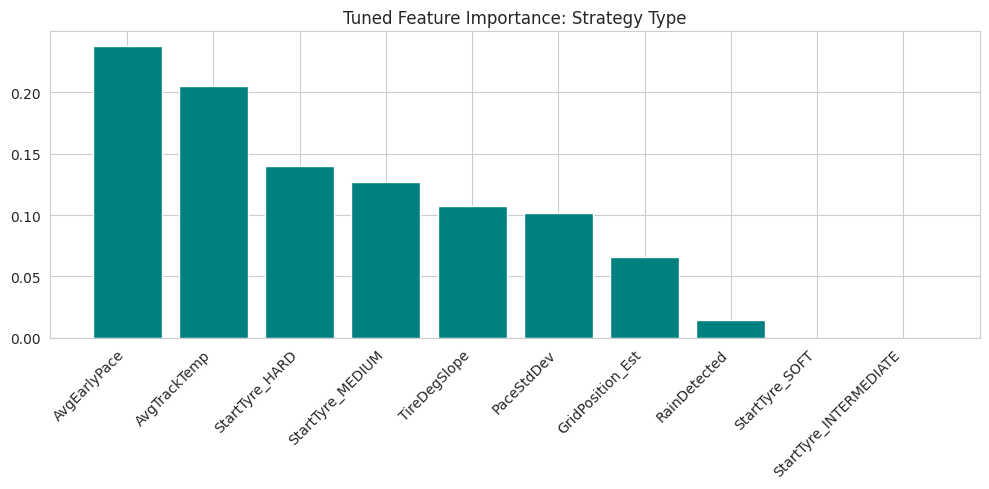

In [56]:
from sklearn.preprocessing import LabelEncoder

def tune_strategy_type_model(df, features):
    """Target: TireSequence (Multiclass Classification)"""
    print("\n" + "="*50)
    print("TUNING MODEL 3: Strategy Type (Multiclass)")
    print("="*50)

    # 1. Filter to Top 5 Strategies to reduce noise from 'chaos' races
    top_strategies = df['TireSequence'].value_counts().head(5).index
    df_filtered = df[df['TireSequence'].isin(top_strategies)].copy()

    # 2. Encode Strategy Strings to Integers
    le = LabelEncoder()
    y_encoded = le.fit_transform(df_filtered['TireSequence'])
    X = df_filtered[features]
    groups = df_filtered['RaceName']

    # 3. Define Grid & LOGO Cross-Validation
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [4, 6, 8],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': ['balanced', 'balanced_subsample'] # Critical for imbalanced strategies
    }

    logo = LeaveOneGroupOut()
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=logo,
        scoring='accuracy',
        n_jobs=-1
    )

    grid_search.fit(X, y_encoded, groups=groups)

    print(f"Best Strategy Params: {grid_search.best_params_}")
    print(f"Best Accuracy: {grid_search.best_score_:.2%}")

    return grid_search.best_estimator_, le

# Update the main block to include this
if __name__ == "__main__":
    df, features = load_and_prep_data()
    if df is not None:
        best_model_strat, label_encoder = tune_strategy_type_model(df, features)
        # Visualization
        plot_importance(best_model_strat, features, "Tuned Feature Importance: Strategy Type")

**Why the class_weight parameter is vital:**

In F1, some strategies (like MEDIUM -> HARD) are much more common than others (like SOFT -> SOFT -> MEDIUM). If we don't use class_weight='balanced', the model might simply learn to predict the most common strategy every time. This parameter "punishes" the model more for missing a rare strategy, forcing it to actually learn the underlying track conditions.

In [57]:
import joblib

joblib.dump(best_model_count, 'f1_pit_count_model_2025.pkl')
joblib.dump(best_model_lap, 'f1_pit_lap_model_2025.pkl')
joblib.dump(best_model_strat, 'f1_strat_model_2025.pkl')

print("models saved")

models saved


## Project Limitations & Critical Thinking
To maintain academic integrity, we must acknowledge the "Chaos Factors" that no model can perfectly predict:

* **The Safety Car (SC/VSC):** A Safety Car at Lap 15 completely "breaks" the predicted strategy, as it offers a "cheap" pit stop that the model cannot foresee.

* **Driver Error**: Crashes or lock-ups that flat-spot tires are random events.

* **Blue Flags**: Drivers in the midfield losing time while being lapped by leaders adds "noise" to their pace data.
* **Historical Bias**: The model assumes 2025 tracks behave like previous 2025 races."
* **NO TELEMETRY**: We used lap-level data only, missing granular wear details.